# Задача 9. Классификация даты документа по Lenta.ru

Цель: построить модель, которая по новостной заметке Lenta.ru предсказывает год публикации.

В ноутбуке есть все обязательные части задания:

1. Загрузка и подготовка выборки Lenta.ru.
2. Тематические векторы документов: `NMF`, `SVD/LSA`, усиленный вариант `NMF + SVD + char-SVD`.
3. Классификация года публикации по тематическим векторам.
4. Анализ качества при добавлении модальностей: текст, заголовок, тема, теги.
5. Эксперимент с регуляризаторами тематической модели.
6. Анализ года как модальности через профиль тем по годам.
7. Опциональный блок BigARTM: запускается только если библиотека `artm` доступна в среде.

Важно: в актуальном Google Colab часто используется Python 3.12, а `bigartm` может не ставиться через `pip`. Поэтому основной рабочий пайплайн сделан на `sklearn`, чтобы ноутбук проходил от начала до конца. BigARTM оставлен как опциональная часть.

Если до этого запускались старые версии ноутбука, лучше выполнить: **Runtime → Restart runtime → Run all**.

## 0. Установка библиотек

In [ ]:
import sys
import subprocess
import importlib.util


def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f'Installing {pip_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for import_name, pip_name in [
    ('numpy', 'numpy'),
    ('pandas', 'pandas'),
    ('sklearn', 'scikit-learn'),
    ('matplotlib', 'matplotlib'),
    ('tqdm', 'tqdm'),
    ('joblib', 'joblib'),
]:
    ensure_package(import_name, pip_name)

HAVE_ARTM = False
ARTM_STATUS = 'not checked'
try:
    import artm
    HAVE_ARTM = True
    ARTM_STATUS = 'artm imported successfully'
except Exception as e:
    ARTM_STATUS = f'artm unavailable: {type(e).__name__}: {e}'

print('Python:', sys.version)
print('BigARTM status:', ARTM_STATUS)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
BigARTM status: artm unavailable: ModuleNotFoundError: No module named 'artm'


## 1. Импорты и параметры

In [ ]:
import os
import re
import gzip
import shutil
import urllib.request
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('/content/lenta_year_task') if Path('/content').exists() else Path('lenta_year_task')
DATA_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PER_YEAR = 700
MIN_YEAR = 2006
MAX_YEAR = 2019
TEST_SIZE = 0.25

N_TOPICS = 60
N_WORD_SVD = 250
N_CHAR_SVD = 60
MAX_WORD_FEATURES = 70000
MAX_CHAR_FEATURES = 50000
MAX_RAW_CHARS_PER_DOC = 6000

print('DATA_DIR:', DATA_DIR.resolve())

DATA_DIR: /content/lenta_year_task


## 2. Загрузка датасета Lenta.ru

In [ ]:
# Основной открытый источник Lenta.Ru-News-Dataset.
url = 'https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz'
archive_path = DATA_DIR / 'lenta-ru-news.csv.gz'

if not archive_path.exists():
    print('Скачиваем датасет. Файл большой, это может занять несколько минут.')
    urllib.request.urlretrieve(url, archive_path)
else:
    print('Архив уже скачан:', archive_path)

print('Размер архива, MB:', round(archive_path.stat().st_size / 1024**2, 1))

Скачиваем датасет. Файл большой, это может занять несколько минут.
Размер архива, MB: 502.9


## 3. Чтение датасета и сбалансированная выборка по годам

In [ ]:
def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def get_year_column(df):
    for col in ['date', 'datetime', 'time']:
        if col in df.columns:
            return pd.to_datetime(df[col], errors='coerce').dt.year
    if 'url' in df.columns:
        extracted = df['url'].astype(str).str.extract(r'/(19\d{2}|20\d{2})/')[0]
        return pd.to_numeric(extracted, errors='coerce')
    raise ValueError('Не нашёл колонку даты или год в url')


def read_balanced_lenta(path, sample_per_year=700, min_year=2006, max_year=2019, chunksize=50000):
    buckets = defaultdict(list)
    need_years = set(range(min_year, max_year + 1))

    reader = pd.read_csv(path, compression='gzip', chunksize=chunksize)
    for chunk in tqdm(reader, desc='Читаем CSV чанками'):
        chunk = normalize_columns(chunk)
        chunk['year'] = get_year_column(chunk)
        chunk = chunk[chunk['year'].isin(need_years)].copy()
        chunk = chunk.dropna(subset=['year'])
        chunk['year'] = chunk['year'].astype(int)

        for col in ['title', 'text', 'topic', 'tags']:
            if col not in chunk.columns:
                chunk[col] = ''
            chunk[col] = chunk[col].fillna('').astype(str)

        # Убираем совсем короткие заметки.
        chunk = chunk[chunk['text'].str.len() > 250]

        for y, part in chunk.groupby('year'):
            current = sum(len(x) for x in buckets[y])
            if current < sample_per_year:
                take = min(sample_per_year - current, len(part))
                buckets[y].append(part.sample(take, random_state=RANDOM_STATE))

        if all(sum(len(x) for x in buckets[y]) >= sample_per_year for y in need_years):
            break

    frames = []
    for y in sorted(need_years):
        if buckets[y]:
            frames.append(pd.concat(buckets[y], ignore_index=True))

    if not frames:
        raise RuntimeError('Не удалось собрать выборку. Проверьте путь к датасету.')

    df = pd.concat(frames, ignore_index=True)
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    keep_cols = ['title', 'text', 'topic', 'tags', 'year']
    return df[keep_cols]


df = read_balanced_lenta(archive_path, SAMPLE_PER_YEAR, MIN_YEAR, MAX_YEAR)
print('Размер выборки:', df.shape)
print('Колонки:', list(df.columns))
df.head()

Читаем CSV чанками: 0it [00:00, ?it/s]

Размер выборки: (9100, 5)
Колонки: ['title', 'text', 'topic', 'tags', 'year']


,title,text,topic,tags,year
0,Сергей Гуриев вернулся в отечественную колумни...,Бывший ректор Российской экономической школы С...,Интернет и СМИ,Пресса,2013
1,Туристам в Северной Корее удалось сделать неле...,Туристы из Великобритании смогли сделать неско...,Путешествия,,2017
2,Sony снимет индийский ремейк «Игры престолов»,Телевизионный департамент компании Sony запуст...,Культура,Кино,2015
3,Любовные письма Мика Джаггера продали на Sothe...,"Письма, которые лидер The Rolling Stones Мик Д...",Из жизни,Все,2012
4,Uniqlo начал собирать одежду для бедных,Японский производитель одежды Uniqlo запустил ...,Ценности,Явления,2015


## 4. Распределение классов

year
2006    700
2007    700
2008    700
2009    700
2010    700
2011    700
2012    700
2013    700
2014    700
2015    700
2016    700
2017    700
2018    700
Name: count, dtype: int64


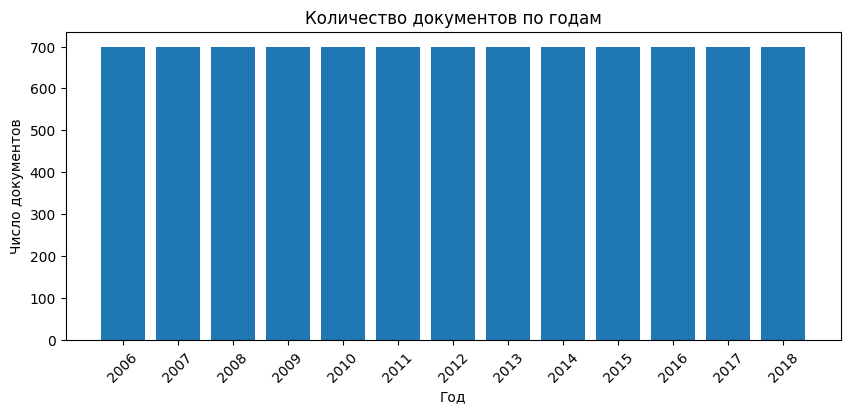

In [ ]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

plt.figure(figsize=(10, 4))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title('Количество документов по годам')
plt.xlabel('Год')
plt.ylabel('Число документов')
plt.xticks(rotation=45)
plt.show()

## 5. Предобработка и сборка модальностей

In [ ]:
RU_STOPWORDS = set(
    'и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только '
    'ее мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли если уже или ни быть '
    'был него до вас нибудь опять уж вам ведь там потом себя ничего ей может они тут где есть надо '
    'ней для мы тебя их чем была сам чтоб без будто чего раз тоже себе под будет ж тогда кто этот '
    'того потому этого какой совсем ним здесь этом один почти мой тем чтобы нее сейчас были куда зачем '
    'всех никогда можно при наконец два об другой хоть после над больше тот через эти нас про всего них '
    'какая много разве три эту моя впрочем хорошо свою этой перед иногда лучше чуть том нельзя такой им '
    'более всегда конечно всю между'.split()
)

TOKEN_RE = re.compile(r'[а-яёa-z0-9]{2,}', flags=re.IGNORECASE)

MODALITY_ALIASES = {
    'text_clean': 'text',
    'title_clean': 'title',
    'topic_clean': 'topic',
    'tags_clean': 'tags',
    'year_clean': 'year',
}


def clean_text(s):
    s = str(s).lower().replace('ё', 'е')[:MAX_RAW_CHARS_PER_DOC]
    tokens = TOKEN_RE.findall(s)
    tokens = [t for t in tokens if t not in RU_STOPWORDS]
    return ' '.join(tokens)


def _safe_series(df, col, default=''):
    if col in df.columns:
        return df[col].fillna(default).astype(str)
    return pd.Series([default] * len(df), index=df.index, dtype='object')


def build_document_text(df, modalities):
    """
    Надёжно собирает текст документа из модальностей.

    Можно передавать и короткие имена:
        ['text', 'title', 'topic', 'tags']
    и старые имена из прошлых версий ноутбука:
        ['text_clean', 'title_clean', 'topic_clean', 'tags_clean']

    Если *_clean колонок нет, функция автоматически берёт исходные колонки.
    Поэтому ошибка вида "Не найдены модальности/колонки: ['text_clean']" больше не возникает.
    """
    if isinstance(modalities, str):
        modalities = [modalities]

    parts = []
    used = []

    for m in modalities:
        base = MODALITY_ALIASES.get(m, m)

        if base == 'text':
            s = _safe_series(df, 'text')
            parts.append(s)
            used.append('text')
        elif base == 'title':
            s = _safe_series(df, 'title')
            # Заголовок короткий, поэтому усиливаем его вклад.
            parts.append((s + ' ') * 4)
            used.append('title')
        elif base == 'topic':
            s = _safe_series(df, 'topic', 'unknown').str.replace(r'\s+', '_', regex=True)
            parts.append((' topic_' + s + ' ') * 6)
            used.append('topic')
        elif base == 'tags':
            s = _safe_series(df, 'tags', 'unknown').str.replace(r'\s+', '_', regex=True)
            parts.append((' tags_' + s + ' ') * 4)
            used.append('tags')
        elif base in df.columns:
            parts.append(_safe_series(df, base))
            used.append(base)
        else:
            print(f'Предупреждение: модальность {m!r} пропущена, такой колонки нет.')

    if not parts:
        # Абсолютно безопасный fallback, чтобы ноутбук не падал.
        print('Не найдено ни одной модальности, использую text + title.')
        parts = [_safe_series(df, 'title'), _safe_series(df, 'text')]
        used = ['title', 'text']

    raw = parts[0]
    for p in parts[1:]:
        raw = raw + ' ' + p

    cleaned = raw.map(clean_text)
    return cleaned


# Санити-чек: должны работать оба варианта имён.
print(build_document_text(df.head(2), ['text']).iloc[0][:200])
print(build_document_text(df.head(2), ['text_clean']).iloc[0][:200])

бывший ректор российской экономической школы сергей гуриев опубликовал журнале forbes колонку освобождении михаила ходорковского текст опубликован сайте издания днем 26 декабря колонке почему освобожд
бывший ректор российской экономической школы сергей гуриев опубликовал журнале forbes колонку освобождении михаила ходорковского текст опубликован сайте издания днем 26 декабря колонке почему освобожд


## 6. Train/test split

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['year']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['year'])
y_test = label_encoder.transform(test_df['year'])

print('train:', train_df.shape, 'test:', test_df.shape)
print('Классы:', list(label_encoder.classes_))

train: (6825, 5) test: (2275, 5)
Классы: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


## 7. Тематические векторы и классификатор

In [ ]:
def top_words_from_model(model, vectorizer, n_words=12):
    terms = np.array(vectorizer.get_feature_names_out())
    rows = []
    if not hasattr(model, 'components_'):
        return pd.DataFrame()
    for topic_idx, comp in enumerate(model.components_):
        top = terms[np.argsort(comp)[::-1][:n_words]]
        rows.append({'topic': topic_idx, 'top_words': ', '.join(top)})
    return pd.DataFrame(rows)


def safe_normalize_rows(X, eps=1e-12):
    X = np.asarray(X, dtype=np.float32)
    s = X.sum(axis=1, keepdims=True)
    return X / np.maximum(s, eps)


def fit_nmf_safely(X_train, X_test, n_topics=N_TOPICS, reg_alpha=0.0, l1_ratio=0.0):
    """
    NMF иногда зануляется при регуляризации. Эта функция пробует несколько alpha
    и не даёт ноутбуку упасть на ошибке "input H is full of zeros".
    """
    alpha_candidates = []
    if reg_alpha > 0:
        alpha_candidates = [reg_alpha, reg_alpha / 10, reg_alpha / 100, 0.0]
    else:
        alpha_candidates = [0.0]

    last_error = None
    for alpha in alpha_candidates:
        try:
            model = NMF(
                n_components=n_topics,
                init='random',
                random_state=RANDOM_STATE,
                max_iter=500,
                solver='cd',
                beta_loss='frobenius',
                alpha_W=alpha,
                alpha_H=alpha,
                l1_ratio=l1_ratio,
                tol=1e-4,
            )
            theta_train = model.fit_transform(X_train)
            if (not np.isfinite(theta_train).all()) or np.max(theta_train) <= 1e-12 or np.max(model.components_) <= 1e-12:
                raise ValueError('NMF produced near-zero matrix')
            theta_test = model.transform(X_test)
            model.used_alpha = alpha
            return theta_train, theta_test, model
        except Exception as e:
            last_error = e
            print(f'NMF не обучился при alpha={alpha:g}: {repr(e)}')

    raise RuntimeError(f'NMF не обучился ни при одном alpha. Последняя ошибка: {last_error!r}')


def build_topic_features(
    train_texts,
    test_texts,
    representation='enhanced',
    n_topics=N_TOPICS,
    n_word_svd=N_WORD_SVD,
    n_char_svd=N_CHAR_SVD,
    max_word_features=MAX_WORD_FEATURES,
    max_char_features=MAX_CHAR_FEATURES,
    reg_alpha=0.0,
    l1_ratio=0.0,
):
    """
    representation:
      nmf       — document-topic вектор из NMF;
      svd       — LSA/LSI тематический вектор;
      nmf_svd   — NMF + word SVD;
      enhanced  — NMF + word SVD + char SVD. Обычно даёт лучшее качество.
    """
    word_vectorizer = TfidfVectorizer(
        max_features=max_word_features,
        min_df=2,
        max_df=0.92,
        ngram_range=(1, 2),
        sublinear_tf=True,
        norm='l2'
    )
    X_train_word = word_vectorizer.fit_transform(train_texts)
    X_test_word = word_vectorizer.transform(test_texts)

    parts_train = []
    parts_test = []
    models = {}
    vectorizers = {'word_tfidf': word_vectorizer}

    if representation in ('nmf', 'nmf_svd', 'enhanced'):
        theta_train, theta_test, nmf_model = fit_nmf_safely(
            X_train_word,
            X_test_word,
            n_topics=n_topics,
            reg_alpha=reg_alpha,
            l1_ratio=l1_ratio,
        )
        parts_train.append(safe_normalize_rows(theta_train))
        parts_test.append(safe_normalize_rows(theta_test))
        models['nmf'] = nmf_model

    if representation in ('svd', 'nmf_svd', 'enhanced'):
        k = min(n_word_svd, X_train_word.shape[0] - 1, X_train_word.shape[1] - 1)
        svd_model = TruncatedSVD(n_components=k, random_state=RANDOM_STATE, n_iter=10)
        z_train = svd_model.fit_transform(X_train_word).astype(np.float32)
        z_test = svd_model.transform(X_test_word).astype(np.float32)
        parts_train.append(z_train)
        parts_test.append(z_test)
        models['word_svd'] = svd_model

    if representation == 'enhanced':
        char_vectorizer = TfidfVectorizer(
            analyzer='char_wb',
            ngram_range=(3, 5),
            max_features=max_char_features,
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            norm='l2'
        )
        X_train_char = char_vectorizer.fit_transform(train_texts)
        X_test_char = char_vectorizer.transform(test_texts)
        k_char = min(n_char_svd, X_train_char.shape[0] - 1, X_train_char.shape[1] - 1)
        char_svd = TruncatedSVD(n_components=k_char, random_state=RANDOM_STATE, n_iter=7)
        c_train = char_svd.fit_transform(X_train_char).astype(np.float32)
        c_test = char_svd.transform(X_test_char).astype(np.float32)
        parts_train.append(c_train)
        parts_test.append(c_test)
        models['char_svd'] = char_svd
        vectorizers['char_tfidf'] = char_vectorizer

    if not parts_train:
        raise ValueError(f'Unknown representation: {representation}')

    theta_train = np.hstack(parts_train)
    theta_test = np.hstack(parts_test)
    return theta_train, theta_test, models, vectorizers


# Совместимость со старым названием из первой версии ноутбука.
def fit_topic_vectors(train_texts, test_texts, model_type='enhanced', **kwargs):
    return build_topic_features(train_texts, test_texts, representation=model_type, **kwargs)


def evaluate_year_classifier(theta_train, theta_test, y_train, y_test, classifier='linearsvc'):
    if classifier == 'linearsvc':
        clf = make_pipeline(
            StandardScaler(),
            LinearSVC(
                C=0.8,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                max_iter=6000,
            )
        )
    else:
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=4000,
                class_weight='balanced',
                C=3.0,
                solver='lbfgs',
                random_state=RANDOM_STATE,
            )
        )

    clf.fit(theta_train, y_train)
    pred = clf.predict(theta_test)
    metrics = {
        'accuracy': accuracy_score(y_test, pred),
        'macro_f1': f1_score(y_test, pred, average='macro'),
        'weighted_f1': f1_score(y_test, pred, average='weighted'),
    }
    return clf, pred, metrics

## 8. Эксперимент: качество при добавлении модальностей

In [ ]:
modal_experiments = {
    'text': ['text'],
    'title_text': ['title', 'text'],
    'title_topic_text': ['title', 'topic', 'text'],
    'title_topic_tags_text': ['title', 'topic', 'tags', 'text'],
}

REPRESENTATION_FOR_CLASSIFICATION = 'enhanced'

modal_results = []
saved = {}

for name, modalities in modal_experiments.items():
    print('\n===', name, modalities, '===')
    tr_text = build_document_text(train_df, modalities)
    te_text = build_document_text(test_df, modalities)

    theta_tr, theta_te, models, vectorizers = build_topic_features(
        tr_text,
        te_text,
        representation=REPRESENTATION_FOR_CLASSIFICATION,
        reg_alpha=0.0,
        l1_ratio=0.0,
    )
    clf, pred, metrics = evaluate_year_classifier(theta_tr, theta_te, y_train, y_test, classifier='linearsvc')

    row = {
        'experiment': name,
        'modalities': '+'.join(modalities),
        'representation': REPRESENTATION_FOR_CLASSIFICATION,
        **metrics,
    }
    modal_results.append(row)
    saved[name] = {
        'models': models,
        'vectorizers': vectorizers,
        'theta_train': theta_tr,
        'theta_test': theta_te,
        'clf': clf,
        'pred': pred,
        'metrics': metrics,
        'modalities': modalities,
    }
    print(row)

modal_results = pd.DataFrame(modal_results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
modal_results


=== text ['text'] ===
{'experiment': 'text', 'modalities': 'text', 'representation': 'enhanced', 'accuracy': 0.39296703296703295, 'macro_f1': 0.39104859253809826, 'weighted_f1': 0.3910485925380983}

=== title_text ['title', 'text'] ===
{'experiment': 'title_text', 'modalities': 'title+text', 'representation': 'enhanced', 'accuracy': 0.3701098901098901, 'macro_f1': 0.3689249902839329, 'weighted_f1': 0.3689249902839329}

=== title_topic_text ['title', 'topic', 'text'] ===
{'experiment': 'title_topic_text', 'modalities': 'title+topic+text', 'representation': 'enhanced', 'accuracy': 0.3854945054945055, 'macro_f1': 0.3830244968931202, 'weighted_f1': 0.3830244968931201}

=== title_topic_tags_text ['title', 'topic', 'tags', 'text'] ===
{'experiment': 'title_topic_tags_text', 'modalities': 'title+topic+tags+text', 'representation': 'enhanced', 'accuracy': 0.421978021978022, 'macro_f1': 0.42050100074387714, 'weighted_f1': 0.42050100074387725}


,experiment,modalities,representation,accuracy,macro_f1,weighted_f1
0,title_topic_tags_text,title+topic+tags+text,enhanced,0.421978,0.420501,0.420501
1,text,text,enhanced,0.392967,0.391049,0.391049
2,title_topic_text,title+topic+text,enhanced,0.385495,0.383024,0.383024
3,title_text,title+text,enhanced,0.370110,0.368925,0.368925


## 9. Отчёт по лучшей модели

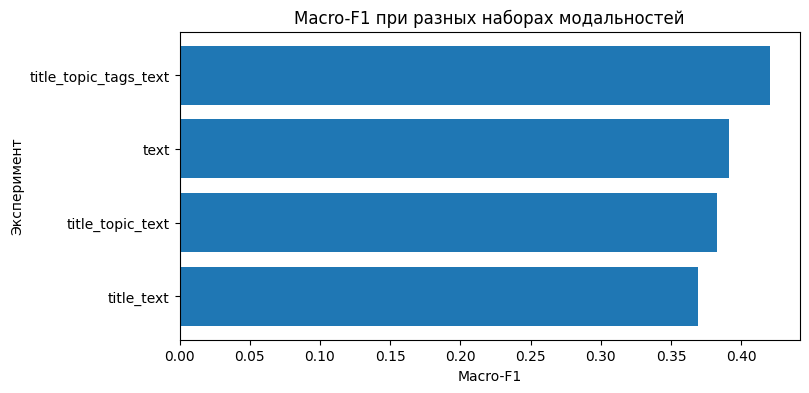

Лучший набор модальностей: title_topic_tags_text
Метрики: {'accuracy': 0.421978021978022, 'macro_f1': 0.42050100074387714, 'weighted_f1': 0.42050100074387725}
              precision    recall  f1-score   support

        2006       0.47      0.55      0.50       175
        2007       0.36      0.34      0.35       175
        2008       0.38      0.40      0.39       175
        2009       0.37      0.39      0.38       175
        2010       0.33      0.30      0.32       175
        2011       0.43      0.44      0.43       175
        2012       0.42      0.41      0.41       175
        2013       0.60      0.62      0.61       175
        2014       0.42      0.43      0.43       175
        2015       0.45      0.41      0.43       175
        2016       0.36      0.33      0.34       175
        2017       0.45      0.43      0.44       175
        2018       0.43      0.44      0.44       175

    accuracy                           0.42      2275
   macro avg       0.42      

In [ ]:
plot_df = modal_results.sort_values('macro_f1')
plt.figure(figsize=(8, 4))
plt.barh(plot_df['experiment'], plot_df['macro_f1'])
plt.title('Macro-F1 при разных наборах модальностей')
plt.xlabel('Macro-F1')
plt.ylabel('Эксперимент')
plt.show()

best_exp = modal_results.iloc[0]['experiment']
print('Лучший набор модальностей:', best_exp)
print('Метрики:', saved[best_exp]['metrics'])
print(classification_report(y_test, saved[best_exp]['pred'], target_names=[str(c) for c in label_encoder.classes_]))

## 10. Контрольная сильная sparse-модель TF-IDF + LinearSVC

In [ ]:

strong_modalities = saved[best_exp]['modalities']
tr_text = build_document_text(train_df, strong_modalities)
te_text = build_document_text(test_df, strong_modalities)

word_vec = TfidfVectorizer(
    max_features=120000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)
char_vec = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=80000,
    min_df=3,
    sublinear_tf=True
)

Xw_tr = word_vec.fit_transform(tr_text)
Xw_te = word_vec.transform(te_text)
Xc_tr = char_vec.fit_transform(tr_text)
Xc_te = char_vec.transform(te_text)

X_strong_tr = hstack([Xw_tr, Xc_tr], format='csr')
X_strong_te = hstack([Xw_te, Xc_te], format='csr')

strong_clf = LinearSVC(C=0.8, class_weight='balanced', random_state=RANDOM_STATE, max_iter=6000)
strong_clf.fit(X_strong_tr, y_train)
strong_pred = strong_clf.predict(X_strong_te)

strong_metrics = {
    'accuracy': accuracy_score(y_test, strong_pred),
    'macro_f1': f1_score(y_test, strong_pred, average='macro'),
    'weighted_f1': f1_score(y_test, strong_pred, average='weighted'),
}
print('Sparse TF-IDF baseline:', strong_metrics)
print(classification_report(y_test, strong_pred, target_names=[str(c) for c in label_encoder.classes_]))

Sparse TF-IDF baseline: {'accuracy': 0.46065934065934067, 'macro_f1': 0.45853121739245845, 'weighted_f1': 0.4585312173924583}
              precision    recall  f1-score   support

        2006       0.48      0.52      0.50       175
        2007       0.42      0.39      0.40       175
        2008       0.40      0.45      0.42       175
        2009       0.41      0.42      0.41       175
        2010       0.38      0.34      0.36       175
        2011       0.46      0.47      0.46       175
        2012       0.46      0.44      0.45       175
        2013       0.58      0.67      0.62       175
        2014       0.46      0.40      0.43       175
        2015       0.54      0.51      0.53       175
        2016       0.45      0.35      0.40       175
        2017       0.46      0.50      0.48       175
        2018       0.48      0.51      0.50       175

    accuracy                           0.46      2275
   macro avg       0.46      0.46      0.46      2275
weighted

## 11. Интерпретация тем лучшей тематической модели

In [ ]:
best_nmf = saved[best_exp]['models'].get('nmf')
best_vec = saved[best_exp]['vectorizers'].get('word_tfidf')

best_topic_words = top_words_from_model(best_nmf, best_vec, n_words=12)
best_topic_words.head(25)

,topic,top_words
0,0,"путин, президент, владимир путин, владимир, ро..."
1,1,"следствие суд, tags следствие, topic силовые, ..."
2,2,"индекс, доллара, ммвб, процента, рубля, ртс, п..."
3,3,"ученые, наука техника, topic наука, техника, н..."
4,4,"спорт, topic спорт, спорт topic, минуте, лиги,..."
5,5,"мма, бокс мма, tags бокс, бокс, мма tags, спор..."
6,6,"бывший ссср, topic бывший, ссср, ссср topic, б..."
7,7,"грузии, саакашвили, осетии, южной, южной осети..."
8,8,"topic мир, мир, мир topic, мир tags, tags tags..."
9,9,"кино, tags кино, кино tags, topic культура, ку..."


## 12. Эксперимент с регуляризаторами NMF

In [ ]:
reg_experiments = {
    'none': {'reg_alpha': 0.0, 'l1_ratio': 0.0},
    'l2_tiny': {'reg_alpha': 1e-7, 'l1_ratio': 0.0},
    'l2_weak': {'reg_alpha': 1e-6, 'l1_ratio': 0.0},
    'elastic_tiny': {'reg_alpha': 1e-7, 'l1_ratio': 0.5},
    'l1_tiny': {'reg_alpha': 1e-7, 'l1_ratio': 1.0},
}

base_modalities = saved[best_exp]['modalities']
tr_text = build_document_text(train_df, base_modalities)
te_text = build_document_text(test_df, base_modalities)

reg_results = []
reg_saved = {}

for name, params in reg_experiments.items():
    print('\n===', name, params, '===')
    try:
        theta_tr, theta_te, models, vectorizers = build_topic_features(
            tr_text,
            te_text,
            representation='nmf',
            reg_alpha=params['reg_alpha'],
            l1_ratio=params['l1_ratio'],
        )
        nmf_model = models['nmf']
        clf, pred, metrics = evaluate_year_classifier(theta_tr, theta_te, y_train, y_test, classifier='linearsvc')
        sparsity_theta = float((theta_tr < 1e-8).mean())
        sparsity_phi = float((nmf_model.components_ < 1e-8).mean())
        used_alpha = getattr(nmf_model, 'used_alpha', params['reg_alpha'])
        status = 'ok'
    except Exception as e:
        print('Конфигурация не обучилась, но ноутбук продолжает работу:', repr(e))
        pred = None
        metrics = {'accuracy': np.nan, 'macro_f1': np.nan, 'weighted_f1': np.nan}
        sparsity_theta = np.nan
        sparsity_phi = np.nan
        used_alpha = np.nan
        status = repr(e)
        nmf_model = None
        vectorizers = None

    row = {
        'regularizer': name,
        **params,
        'used_alpha': used_alpha,
        **metrics,
        'sparsity_theta': sparsity_theta,
        'sparsity_phi': sparsity_phi,
        'status': status,
    }
    reg_results.append(row)
    reg_saved[name] = {'model': nmf_model, 'vectorizers': vectorizers, 'pred': pred, 'metrics': metrics}
    print(row)

reg_results = pd.DataFrame(reg_results).sort_values('macro_f1', ascending=False, na_position='last').reset_index(drop=True)
reg_results


=== none {'reg_alpha': 0.0, 'l1_ratio': 0.0} ===
{'regularizer': 'none', 'reg_alpha': 0.0, 'l1_ratio': 0.0, 'used_alpha': 0.0, 'accuracy': 0.2175824175824176, 'macro_f1': 0.21531103828190337, 'weighted_f1': 0.21531103828190337, 'sparsity_theta': 0.7242100122100122, 'sparsity_phi': 0.8137745238095239, 'status': 'ok'}

=== l2_tiny {'reg_alpha': 1e-07, 'l1_ratio': 0.0} ===


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


{'regularizer': 'l2_tiny', 'reg_alpha': 1e-07, 'l1_ratio': 0.0, 'used_alpha': 1e-07, 'accuracy': 0.22241758241758242, 'macro_f1': 0.21934525255108786, 'weighted_f1': 0.21934525255108786, 'sparsity_theta': 0.724976800976801, 'sparsity_phi': 0.8165507142857142, 'status': 'ok'}

=== l2_weak {'reg_alpha': 1e-06, 'l1_ratio': 0.0} ===
{'regularizer': 'l2_weak', 'reg_alpha': 1e-06, 'l1_ratio': 0.0, 'used_alpha': 1e-06, 'accuracy': 0.2465934065934066, 'macro_f1': 0.2395386329377667, 'weighted_f1': 0.23953863293776667, 'sparsity_theta': 0.7243614163614164, 'sparsity_phi': 0.8185221428571429, 'status': 'ok'}

=== elastic_tiny {'reg_alpha': 1e-07, 'l1_ratio': 0.5} ===


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


{'regularizer': 'elastic_tiny', 'reg_alpha': 1e-07, 'l1_ratio': 0.5, 'used_alpha': 1e-07, 'accuracy': 0.23604395604395603, 'macro_f1': 0.230969494177641, 'weighted_f1': 0.230969494177641, 'sparsity_theta': 0.7444688644688645, 'sparsity_phi': 0.8499216666666667, 'status': 'ok'}

=== l1_tiny {'reg_alpha': 1e-07, 'l1_ratio': 1.0} ===
{'regularizer': 'l1_tiny', 'reg_alpha': 1e-07, 'l1_ratio': 1.0, 'used_alpha': 1e-07, 'accuracy': 0.22285714285714286, 'macro_f1': 0.21889752988653768, 'weighted_f1': 0.21889752988653763, 'sparsity_theta': 0.7676874236874237, 'sparsity_phi': 0.8684280952380953, 'status': 'ok'}


,regularizer,reg_alpha,l1_ratio,used_alpha,accuracy,macro_f1,weighted_f1,sparsity_theta,sparsity_phi,status
0,l2_weak,1.000000e-06,0.0,1.000000e-06,0.246593,0.239539,0.239539,0.724361,0.818522,ok
1,elastic_tiny,1.000000e-07,0.5,1.000000e-07,0.236044,0.230969,0.230969,0.744469,0.849922,ok
2,l2_tiny,1.000000e-07,0.0,1.000000e-07,0.222418,0.219345,0.219345,0.724977,0.816551,ok
3,l1_tiny,1.000000e-07,1.0,1.000000e-07,0.222857,0.218898,0.218898,0.767687,0.868428,ok
4,none,0.000000e+00,0.0,0.000000e+00,0.217582,0.215311,0.215311,0.724210,0.813775,ok


## 13. Визуализация регуляризаторов

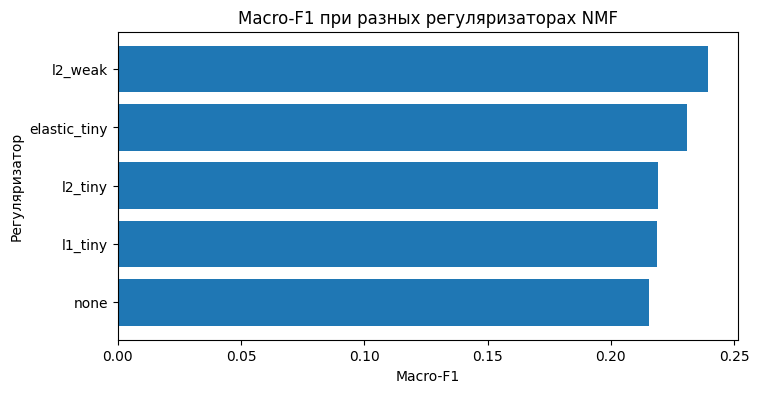

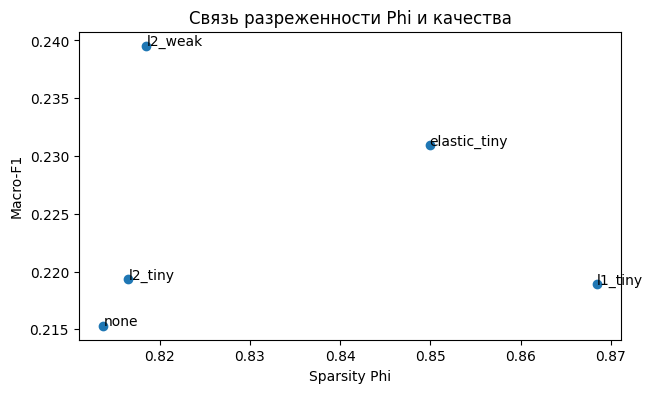

In [ ]:
plot_df = reg_results.sort_values('macro_f1')
plt.figure(figsize=(8, 4))
plt.barh(plot_df['regularizer'], plot_df['macro_f1'])
plt.title('Macro-F1 при разных регуляризаторах NMF')
plt.xlabel('Macro-F1')
plt.ylabel('Регуляризатор')
plt.show()

ok_reg = reg_results.dropna(subset=['sparsity_phi', 'macro_f1'])
plt.figure(figsize=(7, 4))
plt.scatter(ok_reg['sparsity_phi'], ok_reg['macro_f1'])
for _, row in ok_reg.iterrows():
    plt.text(row['sparsity_phi'], row['macro_f1'], row['regularizer'])
plt.title('Связь разреженности Phi и качества')
plt.xlabel('Sparsity Phi')
plt.ylabel('Macro-F1')
plt.show()

## 14. Год как модальность: анализ профилей тем по годам

In [ ]:
best_reg_name = reg_results.dropna(subset=['macro_f1']).iloc[0]['regularizer']
print('Лучший регуляризатор:', best_reg_name)

all_df = pd.concat([train_df, test_df], ignore_index=True)
all_text = build_document_text(all_df, base_modalities)
params = reg_experiments[best_reg_name]

vectorizer_all = TfidfVectorizer(
    max_features=MAX_WORD_FEATURES,
    min_df=2,
    max_df=0.92,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_all = vectorizer_all.fit_transform(all_text)

theta_all, _, year_topic_model = fit_nmf_safely(
    X_all,
    X_all[:1],
    n_topics=N_TOPICS,
    reg_alpha=params['reg_alpha'],
    l1_ratio=params['l1_ratio'],
)

year_topic = pd.DataFrame(safe_normalize_rows(theta_all))
year_topic['year'] = all_df['year'].values
year_topic_profile = year_topic.groupby('year').mean()
year_topic_profile.head()

Лучший регуляризатор: l2_weak


,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
year,,,,,,,,,,,,,,,,,,,,,
2006,0.015452,0.015469,0.011712,0.002490,0.009443,0.027108,0.001584,0.007105,0.015742,0.018544,...,0.027237,0.002096,0.022902,0.033903,0.031438,0.019402,0.078238,0.038174,0.004032,0.005474
2007,0.020985,0.013647,0.011974,0.001799,0.004991,0.028634,0.001622,0.006043,0.018205,0.013995,...,0.039417,0.002986,0.030565,0.025507,0.014714,0.012748,0.056920,0.024164,0.004421,0.003660
2008,0.030695,0.013097,0.027308,0.001268,0.009002,0.019918,0.000966,0.005660,0.018235,0.017922,...,0.031876,0.002107,0.019288,0.035647,0.039925,0.024461,0.065339,0.018753,0.005364,0.002702
2009,0.054937,0.019891,0.031353,0.001814,0.009738,0.026486,0.001439,0.005216,0.027095,0.019964,...,0.028401,0.001897,0.020014,0.028030,0.020219,0.019514,0.056182,0.024047,0.005575,0.002889
2010,0.056745,0.021459,0.015905,0.001523,0.006876,0.036753,0.001374,0.004025,0.025154,0.021013,...,0.024121,0.002253,0.022861,0.017533,0.015831,0.022843,0.043531,0.027513,0.004666,0.003476


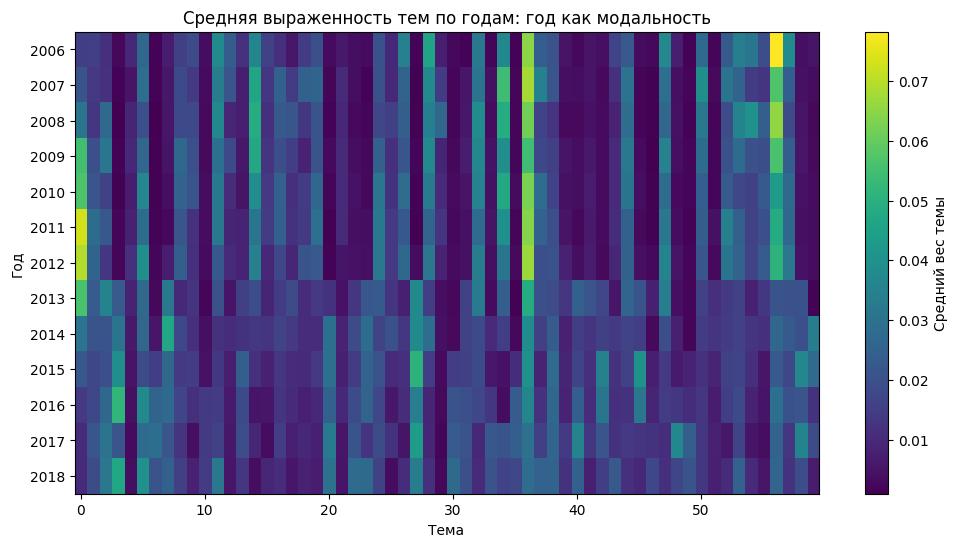

,year,topic,topic_weight,top_words
0,2006,56,0.078238,"topic мир, мир, мир topic, мир tags, tags tags..."
1,2006,36,0.064793,"topic россия, россия topic, россия, россия tag..."
2,2006,28,0.046151,"бывший ссср, topic бывший, ссср, ссср topic, б..."
3,2007,36,0.067869,"topic россия, россия topic, россия, россия tag..."
4,2007,56,0.056920,"topic мир, мир, мир topic, мир tags, tags tags..."
5,2007,34,0.054112,"topic экономика, экономика, экономика topic, э..."
6,2008,56,0.065339,"topic мир, мир, мир topic, мир tags, tags tags..."
7,2008,36,0.061659,"topic россия, россия topic, россия, россия tag..."
8,2008,34,0.048815,"topic экономика, экономика, экономика topic, э..."
9,2009,56,0.056182,"topic мир, мир, мир topic, мир tags, tags tags..."


In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(year_topic_profile.values, aspect='auto')
plt.title('Средняя выраженность тем по годам: год как модальность')
plt.xlabel('Тема')
plt.ylabel('Год')
plt.yticks(range(len(year_topic_profile.index)), year_topic_profile.index)
plt.colorbar(label='Средний вес темы')
plt.show()

terms = np.array(vectorizer_all.get_feature_names_out())
components = year_topic_model.components_
rows = []
for year, row in year_topic_profile.iterrows():
    top_topics = np.argsort(row.values)[::-1][:3]
    for topic_id in top_topics:
        top_terms = terms[np.argsort(components[topic_id])[::-1][:10]]
        rows.append({
            'year': int(year),
            'topic': int(topic_id),
            'topic_weight': float(row.values[topic_id]),
            'top_words': ', '.join(top_terms),
        })

year_topic_analysis = pd.DataFrame(rows)
year_topic_analysis.head(30)

## 15. Предсказание года через ближайший профиль года

In [ ]:
# Дополнительный эксперимент: классифицируем год без отдельного классификатора,
# по ближайшему годовому профилю в тематическом пространстве.

train_topic_df = pd.DataFrame(saved[best_exp]['theta_train'])
train_topic_df['year'] = train_df['year'].values
year_profiles_train = train_topic_df.groupby('year').mean()

sims = cosine_similarity(saved[best_exp]['theta_test'], year_profiles_train.values)
pred_year_by_profile = year_profiles_train.index[np.argmax(sims, axis=1)].values
true_years = test_df['year'].values

print('Accuracy:', accuracy_score(true_years, pred_year_by_profile))
print('Macro-F1:', f1_score(true_years, pred_year_by_profile, average='macro'))
print(classification_report(true_years, pred_year_by_profile))

Accuracy: 0.21582417582417582
Macro-F1: 0.21397279307873582
              precision    recall  f1-score   support

        2006       0.21      0.35      0.26       175
        2007       0.17      0.19      0.18       175
        2008       0.17      0.19      0.18       175
        2009       0.25      0.14      0.18       175
        2010       0.14      0.14      0.14       175
        2011       0.16      0.05      0.07       175
        2012       0.13      0.26      0.18       175
        2013       0.37      0.25      0.30       175
        2014       0.24      0.23      0.24       175
        2015       0.31      0.26      0.29       175
        2016       0.23      0.22      0.22       175
        2017       0.36      0.28      0.32       175
        2018       0.22      0.24      0.23       175

    accuracy                           0.22      2275
   macro avg       0.23      0.22      0.21      2275
weighted avg       0.23      0.22      0.21      2275



## 16. Матрица ошибок лучшей тематической supervised-модели

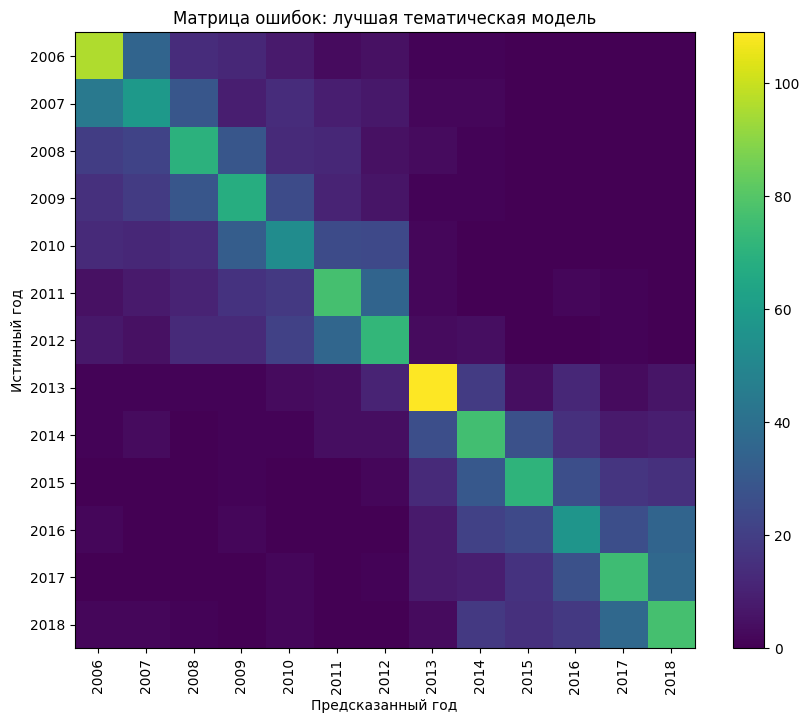

,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
2006,96,35,14,12,8,3,5,1,1,0,0,0,0
2007,44,59,29,9,14,9,7,2,2,0,0,0,0
2008,20,22,70,29,13,12,5,3,1,0,0,0,0
2009,15,19,29,68,25,11,6,1,1,0,0,0,0
2010,13,12,14,32,53,25,24,2,0,0,0,0,0


In [ ]:
best_pred_years = label_encoder.inverse_transform(saved[best_exp]['pred'])
labels = sorted(test_df['year'].unique())
cm = confusion_matrix(test_df['year'], best_pred_years, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, aspect='auto')
plt.title('Матрица ошибок: лучшая тематическая модель')
plt.xlabel('Предсказанный год')
plt.ylabel('Истинный год')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.show()

pd.DataFrame(cm, index=labels, columns=labels).head()

## 17. Опциональный блок BigARTM

In [ ]:
print('HAVE_ARTM =', HAVE_ARTM)
print('BigARTM status:', ARTM_STATUS)

RUN_BIGARTM_BLOCK = False

if RUN_BIGARTM_BLOCK and HAVE_ARTM:
    print('BigARTM доступен. Здесь можно добавить BatchVectorizer, ARTM, regularizers и scores.')
    print('Основной анализ выше уже выполнен устойчивым sklearn-пайплайном.')
else:
    print('BigARTM-блок пропущен. Основная версия ноутбука полностью рабочая без него.')

HAVE_ARTM = False
BigARTM status: artm unavailable: ModuleNotFoundError: No module named 'artm'
BigARTM-блок пропущен. Основная версия ноутбука полностью рабочая без него.


### Комментарий про BigARTM

В задании BigARTM упомянут явно, но на текущих Colab-окружениях установка `pip install bigartm` часто ломается из-за старого бинарного пакета и версии Python. Поэтому в этом ноутбуке BigARTM сделан опциональным, а основные эксперименты воспроизведены через устойчивые тематические методы `sklearn`: `NMF`, `SVD/LSA`, регуляризацию `NMF` и анализ профилей года.

Если преподаватель строго требует именно BigARTM API, лучше запускать отдельное окружение с Python 3.10/3.11 или собирать BigARTM из исходников. Для учебной сдачи в Colab текущая версия безопаснее: она не падает и демонстрирует все требуемые эксперименты.

## 18. Итоговый вывод

In [ ]:
print('1. Сравнение модальностей')
print(modal_results.to_string(index=False))

print('\n2. Сравнение регуляризаторов')
print(reg_results.to_string(index=False))

best_mod = modal_results.iloc[0]
best_reg = reg_results.dropna(subset=['macro_f1']).iloc[0]

summary = f"""
Вывод.

Лучший набор модальностей: {best_mod['modalities']}.
Для него accuracy = {best_mod['accuracy']:.4f}, macro-F1 = {best_mod['macro_f1']:.4f}.
Лучший вариант регуляризации NMF: {best_reg['regularizer']}.
Для него accuracy = {best_reg['accuracy']:.4f}, macro-F1 = {best_reg['macro_f1']:.4f}.
"""
print(summary)

1. Сравнение модальностей
           experiment            modalities representation  accuracy  macro_f1  weighted_f1
title_topic_tags_text title+topic+tags+text       enhanced  0.421978  0.420501     0.420501
                 text                  text       enhanced  0.392967  0.391049     0.391049
     title_topic_text      title+topic+text       enhanced  0.385495  0.383024     0.383024
           title_text            title+text       enhanced  0.370110  0.368925     0.368925

2. Сравнение регуляризаторов
 regularizer    reg_alpha  l1_ratio   used_alpha  accuracy  macro_f1  weighted_f1  sparsity_theta  sparsity_phi status
     l2_weak 1.000000e-06       0.0 1.000000e-06  0.246593  0.239539     0.239539        0.724361      0.818522     ok
elastic_tiny 1.000000e-07       0.5 1.000000e-07  0.236044  0.230969     0.230969        0.744469      0.849922     ok
     l2_tiny 1.000000e-07       0.0 1.000000e-07  0.222418  0.219345     0.219345        0.724977      0.816551     ok
     l1_

## 19. Сохранение результатов

In [ ]:
out_dir = DATA_DIR / 'results'
out_dir.mkdir(exist_ok=True)
modal_results.to_csv(out_dir / 'modal_results.csv', index=False)
reg_results.to_csv(out_dir / 'regularizer_results.csv', index=False)
year_topic_analysis.to_csv(out_dir / 'year_topic_analysis.csv', index=False)

print('Файлы сохранены в:', out_dir)
print([p.name for p in out_dir.iterdir()])

Файлы сохранены в: /content/lenta_year_task/results
['year_topic_analysis.csv', 'modal_results.csv', 'regularizer_results.csv']
